# PCD Assignment 02: Image Enhancement

* **Nama:** Muhammad Gauza Faliha
* **NIM:** 25/555851/PA/23315
* **Prodi:** Ilmu Komputer
* **Mata Kuliah:** Pengolahan Citra Digital

Pada notebook ini saya mengimplementasikan beberapa teknik image enhancement untuk mengatasi lima permasalahan citra, yaitu citra low light, over exposed, low contrast, blur, dan noisy.

In [1]:
# Instalasi pustaka yang dibutuhkan
!pip install numpy opencv-python matplotlib

  Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp313-cp313-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp313-cp313-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.66.0-

## 1. Import Library

Mengimpor pustaka inti yang dibutuhkan untuk membaca data, manipulasi array piksel, pemrosesan citra digital, dan visualisasi grafik.

In [2]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 2. Definisi Fungsi Pemrosesan dan Visualisasi

Setiap fungsi dibuat terpisah sesuai kelompok kegunaannya agar kode mudah dibaca, modular, dan dapat dipanggil berulang kali di dalam loop pemrosesan.

### 2.1 Fungsi Pemuatan Dataset Citra

Membaca seluruh berkas citra dari dalam folder secara otomatis dan mengonversi format warna BGR ke RGB.

In [3]:
def load_images_from_folder(folder_path):
    images = []
    filenames = []
    for path in sorted(glob.glob(os.path.join(folder_path, "*"))):
        if os.path.isfile(path):
            img = cv2.imread(path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img_rgb)
                filenames.append(os.path.basename(path))
    return images, filenames

### 2.2 Fungsi Visualisasi Hasil dan Histogram

Fungsi untuk menampilkan perbandingan visual citra sebelum dan sesudah diproses, serta menampilkan kurva histogram distribusi intensitas piksel.

In [4]:
def tampilkan_perbandingan(daftar_gambar, daftar_judul):
    jumlah = len(daftar_gambar)
    fig, axes = plt.subplots(1, jumlah, figsize=(4.5 * jumlah, 4.5))
    if jumlah == 1:
        axes = [axes]
    for ax, gambar, judul in zip(axes, daftar_gambar, daftar_judul):
        if len(gambar.shape) == 2:
            ax.imshow(gambar, cmap="gray")
        else:
            ax.imshow(gambar)
        ax.set_title(judul, fontsize=11, fontweight="bold")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [5]:
def tampilkan_histogram(daftar_gambar, daftar_judul):
    warna = ("r", "g", "b")
    jumlah = len(daftar_gambar)
    fig, axes = plt.subplots(1, jumlah, figsize=(4.5 * jumlah, 3.8))
    if jumlah == 1:
        axes = [axes]
    for ax, gambar, judul in zip(axes, daftar_gambar, daftar_judul):
        if len(gambar.shape) == 2:
            hist = cv2.calcHist([gambar], [0], None, [256], [0, 256])
            ax.plot(hist, color="black", linewidth=1.5)
        else:
            for i, c in enumerate(warna):
                hist = cv2.calcHist([gambar], [i], None, [256], [0, 256])
                ax.plot(hist, color=c, linewidth=1.5)
        ax.set_title(judul, fontsize=11, fontweight="bold")
        ax.set_xlim([0, 256])
        ax.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

### 2.3 Fungsi Transformasi Titik Piksel (Pixel Based Enhancement)

Operasi titik yang memodifikasi nilai keabuan setiap piksel secara mandiri tanpa bergantung pada piksel tetangga.

In [6]:
# 1. Transformasi Image Negative
def image_negative(img):
    return 255 - img

In [7]:
# 2. Transformasi Logaritmik (Log Transform)
def log_transform(img):
    img_float = img.astype(np.float64)
    c = 255.0 / np.log(1.0 + np.max(img_float))
    result = c * np.log(1.0 + img_float)
    return np.uint8(np.clip(result, 0, 255))

In [8]:
# 3. Transformasi Hukum Pangkat (Gamma Transform)
def gamma_transform(img, gamma):
    img_norm = img.astype(np.float64) / 255.0
    result = np.power(img_norm, gamma) * 255.0
    return np.uint8(np.clip(result, 0, 255))

In [9]:
# 4. Peregangan Kontras (Contrast Stretching)
def contrast_stretching(img):
    min_val = np.min(img)
    max_val = np.max(img)
    if max_val == min_val:
        return img
    result = (img.astype(np.float64) - min_val) * (255.0 / (max_val - min_val))
    return np.uint8(np.clip(result, 0, 255))

### 2.4 Fungsi Histogram Processing

Perataan histogram pada kanal Value dalam ruang warna HSV agar meningkatkan kontras tanpa mengubah warna asli citra.

In [10]:
# 5. Histogram Equalization Citra Berwarna (Kanal V pada HSV)
def histogram_equalization_color(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    v_eq = cv2.equalizeHist(v)
    hasil = cv2.merge([h, s, v_eq])
    return cv2.cvtColor(hasil, cv2.COLOR_HSV2RGB)

### 2.5 Fungsi Slicing Intensitas dan Bidang Bit

Operasi untuk menonjolkan interval nilai keabuan tertentu dan memecah citra ke dalam delapan bidang bit biner.

In [11]:
# 6. Pemotongan Tingkat Keabuan (Gray Level Slicing)
def gray_level_slicing(img, batas_bawah, batas_atas):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hasil = np.where((gray >= batas_bawah) & (gray <= batas_atas), 255, gray)
    return hasil.astype(np.uint8)

In [12]:
# 7. Pemotongan Bidang Bit (Bit Plane Slicing)
def bit_plane_slicing(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    bidang_bit = []
    for i in range(8):
        bit = (gray >> i) & 1
        bidang_bit.append(bit * 255)
    return bidang_bit

### 2.6 Fungsi Spatial Smoothing Filter

Operasi konvolusi spasial untuk menghaluskan citra dan mereduksi derau menggunakan jendela tetangga lokal.

In [13]:
# 8. Filter Rata Rata (Mean Filter)
def mean_filter(img, ukuran_kernel):
    return cv2.blur(img, (ukuran_kernel, ukuran_kernel))

In [14]:
# 9. Filter Gaussian
def gaussian_filter(img, sigma):
    return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)

In [15]:
# 10. Filter Median
def median_filter(img, ukuran_kernel):
    return cv2.medianBlur(img, ukuran_kernel)

### 2.7 Fungsi Spatial Sharpening Filter

Operasi turunan spasial untuk mempertegas batas tepi objek yang kabur.

In [16]:
# 11. Penajaman Laplacian
def laplacian_sharpening(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    hasil = gray.astype(np.float64) - laplacian
    return np.uint8(np.clip(hasil, 0, 255))

In [17]:
# 12. Penajaman Unsharp Masking
def unsharp_masking(img, sigma, alpha):
    smoothed = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(img, 1.0 + alpha, smoothed, -alpha, 0)

## 3. Load Dataset Otomatis

Memuat seluruh citra dari masing masing folder kategori ke dalam dictionary menggunakan perulangan.

In [18]:
kategori_list = ["low-light-image", "over-exposed", "low-contrast", "blur", "noisy"]
dataset = {}

for kategori in kategori_list:
    folder_path = os.path.join("images", kategori)
    gambar, nama_file = load_images_from_folder(folder_path)
    dataset[kategori] = {"gambar": gambar, "nama_file": nama_file}
    print(f"Kategori {kategori} berhasil dimuat sejumlah {len(gambar)} citra: {nama_file}")

Kategori low-light-image berhasil dimuat sejumlah 1 citra: ['low-light-image.png']
Kategori over-exposed berhasil dimuat sejumlah 1 citra: ['over-exposured.jpg']
Kategori low-contrast berhasil dimuat sejumlah 1 citra: ['low-contrast.png']
Kategori blur berhasil dimuat sejumlah 1 citra: ['blur.jpg']
Kategori noisy berhasil dimuat sejumlah 1 citra: ['noisy.jpg']


## 4. Eksplorasi Awal Citra dan Histogram

Melihat kondisi visual awal citra beserta bentuk persebaran histogramnya sebelum diterapkan teknik perbaikan.

Eksplorasi awal kategori low-light-image (low-light-image.png):


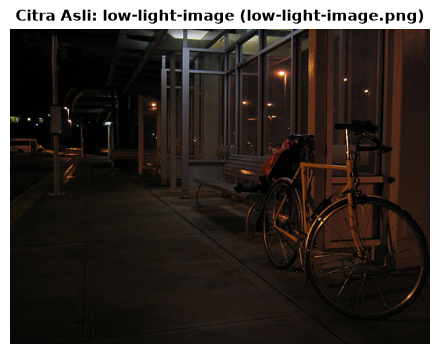

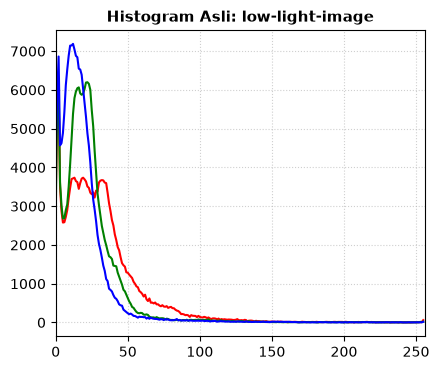

Eksplorasi awal kategori over-exposed (over-exposured.jpg):


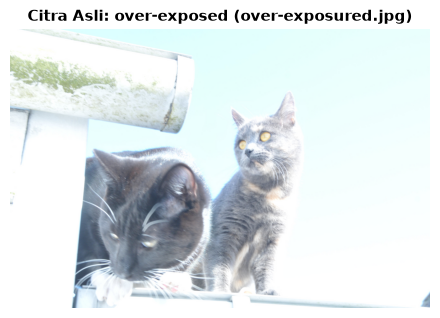

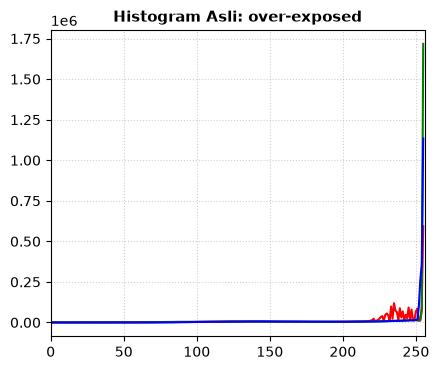

Eksplorasi awal kategori low-contrast (low-contrast.png):


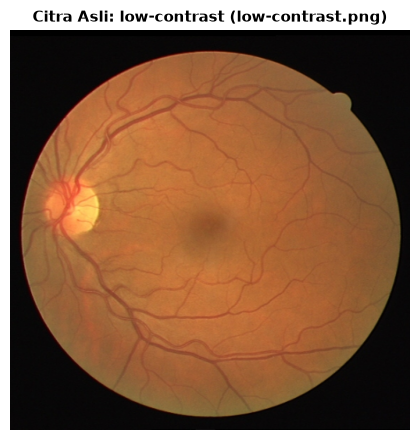

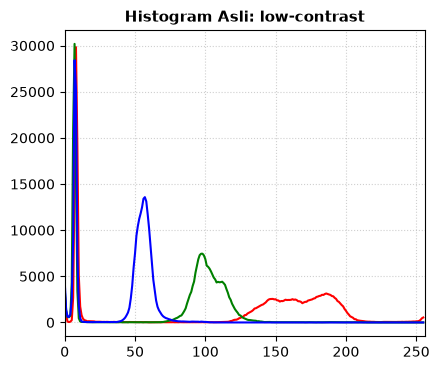

Eksplorasi awal kategori blur (blur.jpg):


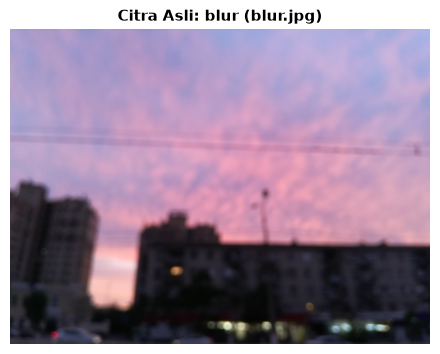

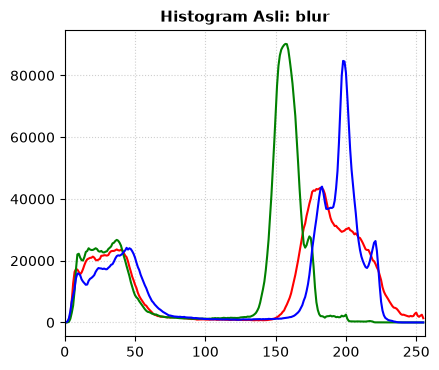

Eksplorasi awal kategori noisy (noisy.jpg):


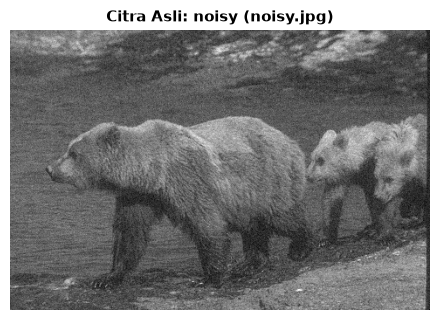

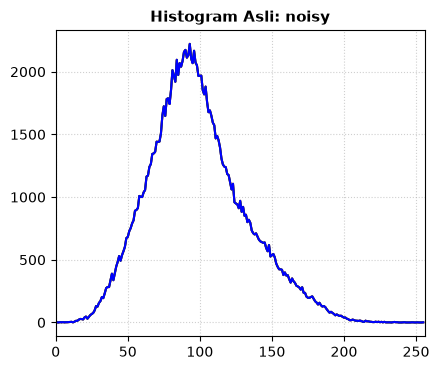

In [19]:
for kategori in kategori_list:
    for g, n in zip(dataset[kategori]["gambar"], dataset[kategori]["nama_file"]):
        print(f"Eksplorasi awal kategori {kategori} ({n}):")
        tampilkan_perbandingan([g], [f"Citra Asli: {kategori} ({n})"])
        tampilkan_histogram([g], [f"Histogram Asli: {kategori}"])

### Analisis Karakteristik Citra Awal

Berdasarkan grafik histogram terlihat bahwa citra low light memiliki piksel yang menumpuk di sisi kiri mendekati nilai 0. Citra over exposed menumpuk di sisi kanan mendekati nilai 255. Citra low contrast memiliki rentang sempit di bagian tengah. Citra blur memiliki gradien tepi yang rendah, dan citra noisy memuat gangguan bintik bintik acak.

## 5. Enhancement Kategori Low Light Image

Menerapkan image negative, log transform, gamma transform gamma 0.4, dan histogram equalization pada citra minim cahaya.

Perbandingan visual citra low light (low-light-image.png):


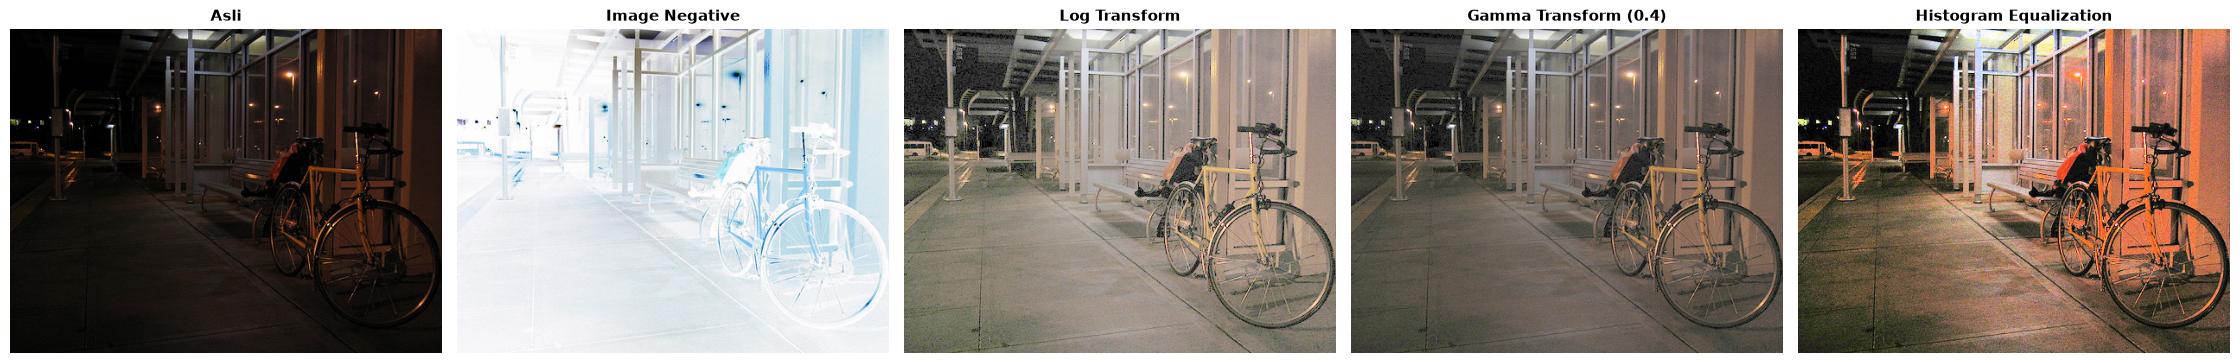

Perbandingan histogram citra low light (low-light-image.png):


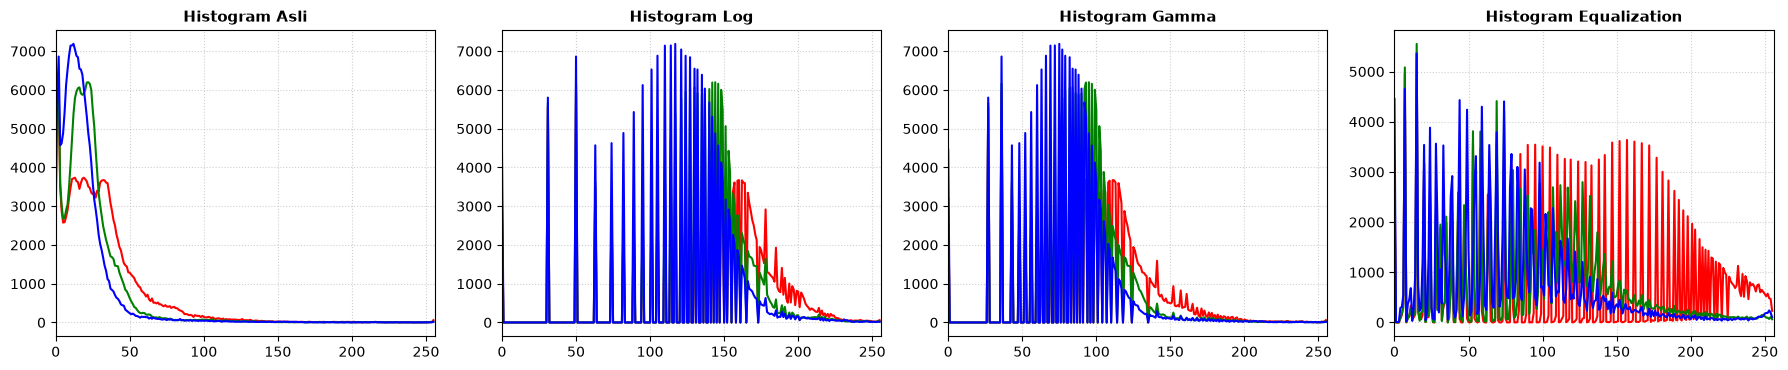

In [20]:
for gambar, nama in zip(dataset["low-light-image"]["gambar"], dataset["low-light-image"]["nama_file"]):
    hasil_neg = image_negative(gambar)
    hasil_log = log_transform(gambar)
    hasil_gamma = gamma_transform(gambar, gamma=0.4)
    hasil_eq = histogram_equalization_color(gambar)
    
    print(f"Perbandingan visual citra low light ({nama}):")
    tampilkan_perbandingan([gambar, hasil_neg, hasil_log, hasil_gamma, hasil_eq],
                            ["Asli", "Image Negative", "Log Transform", "Gamma Transform (0.4)", "Histogram Equalization"])
    
    print(f"Perbandingan histogram citra low light ({nama}):")
    tampilkan_histogram([gambar, hasil_log, hasil_gamma, hasil_eq],
                         ["Histogram Asli", "Histogram Log", "Histogram Gamma", "Histogram Equalization"])

### Penjelasan Hasil Percobaan Kategori Low Light

Metode yang diuji adalah log transform dengan rumus s = c log(1 + r), gamma transform dengan rumus s = c r^gamma pada gamma bernilai 0.4, image negative dengan rumus s = (L - 1) - r, dan histogram equalization pada kanal Value HSV.

Teknik transformasi non linier ini dipilih karena mampu meregangkan nilai intensitas gelap yang padat tanpa membuat area terang menjadi silau, sedangkan histogram equalization meratakan distribusi piksel ke seluruh rentang dinamis.

Secara visual, gamma transform 0.4 menghasilkan pencahayaan yang paling natural dengan detail latar belakang yang tampak jelas. Histogram menunjukkan persebaran piksel bergeser dari tumpukan di sisi kiri menuju ke rentang tengah dan kanan. Log transform menaikkan kecerahan secara agresif namun sedikit memudarkan kontras. Histogram equalization menghasilkan kontras warna yang hidup. Image negative membalik intensitas gelap menjadi terang pada latar putih.

Gamma transform 0.4 dan histogram equalization terbukti paling efektif memulihkan detail objek pada citra low light secara seimbang.

## 6. Enhancement Kategori Over Exposed

Menerapkan gamma transform gamma 2.2, contrast stretching, dan image negative pada citra yang mengalami kelebihan pencahayaan.

Perbandingan visual citra over exposed (over-exposured.jpg):


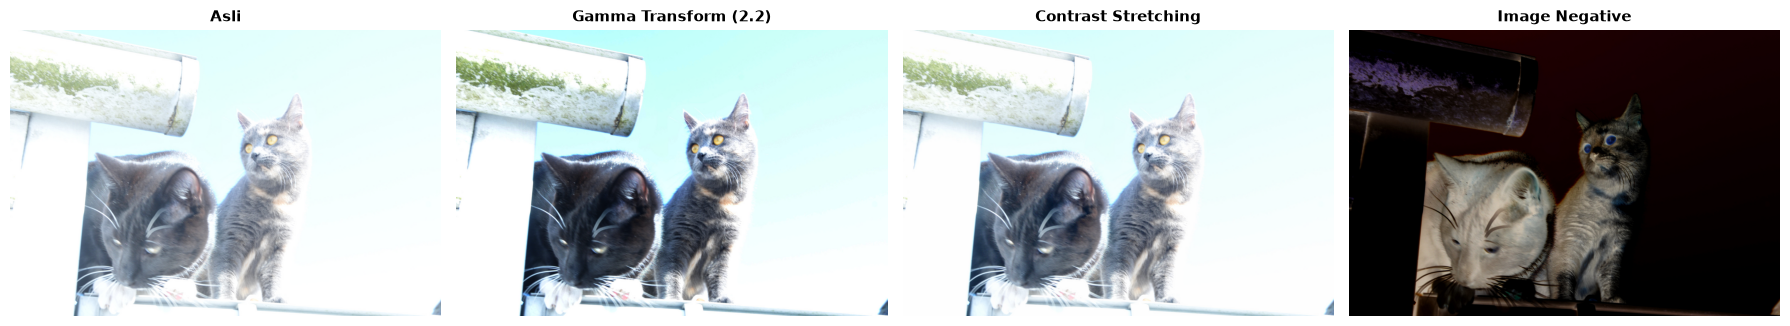

Perbandingan histogram citra over exposed (over-exposured.jpg):


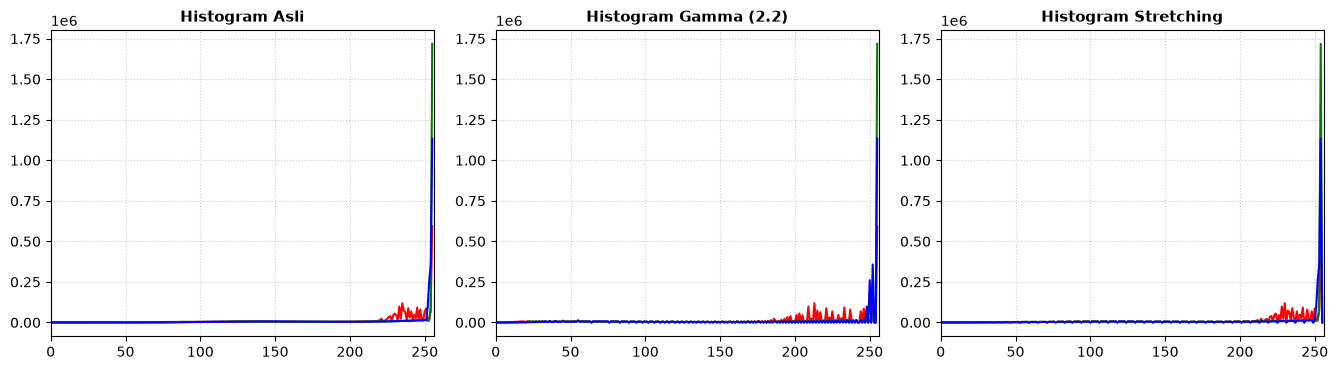

In [21]:
for gambar, nama in zip(dataset["over-exposed"]["gambar"], dataset["over-exposed"]["nama_file"]):
    hasil_gamma = gamma_transform(gambar, gamma=2.2)
    hasil_stretch = contrast_stretching(gambar)
    hasil_neg = image_negative(gambar)
    
    print(f"Perbandingan visual citra over exposed ({nama}):")
    tampilkan_perbandingan([gambar, hasil_gamma, hasil_stretch, hasil_neg],
                            ["Asli", "Gamma Transform (2.2)", "Contrast Stretching", "Image Negative"])
    
    print(f"Perbandingan histogram citra over exposed ({nama}):")
    tampilkan_histogram([gambar, hasil_gamma, hasil_stretch],
                         ["Histogram Asli", "Histogram Gamma (2.2)", "Histogram Stretching"])

### Penjelasan Hasil Percobaan Kategori Over Exposed

Metode yang diuji adalah gamma transform dengan rumus s = c r^gamma pada gamma bernilai 2.2, contrast stretching dengan rumus P_out = (P_in - Min) dikali 255 per (Max - Min), dan image negative sebagai pembanding inversi.

Citra over exposed memiliki piksel yang menumpuk ekstrem di area terang. Gamma transform dengan nilai gamma lebih dari satu sangat cocok karena mampu menekan nilai intensitas tinggi dan meregangkan intensitas rendah sehingga detail permukaan objek yang silau bisa tampak kembali.

Secara visual, gamma transform 2.2 berhasil meredam area silau dan memunculkan kembali tekstur permukaan objek yang sebelumnya pudar tertutup cahaya putih. Pada histogram tampak puncak piksel di sisi kanan berhasil ditarik melebar ke arah intensitas tengah. Contrast stretching sedikit merentangkan batas nilai piksel, sedangkan image negative membalik area terang menjadi gelap.

Gamma transform dengan gamma 2.2 terbukti paling efektif memulihkan tekstur dan mengatasi saturasi berlebih pada citra over exposed.

## 7. Enhancement Kategori Low Contrast

Menerapkan contrast stretching, histogram equalization, gray level slicing 80 sampai 180, serta bedah bit plane slicing pada citra berkontras rendah.

Perbandingan visual citra low contrast (low-contrast.png):


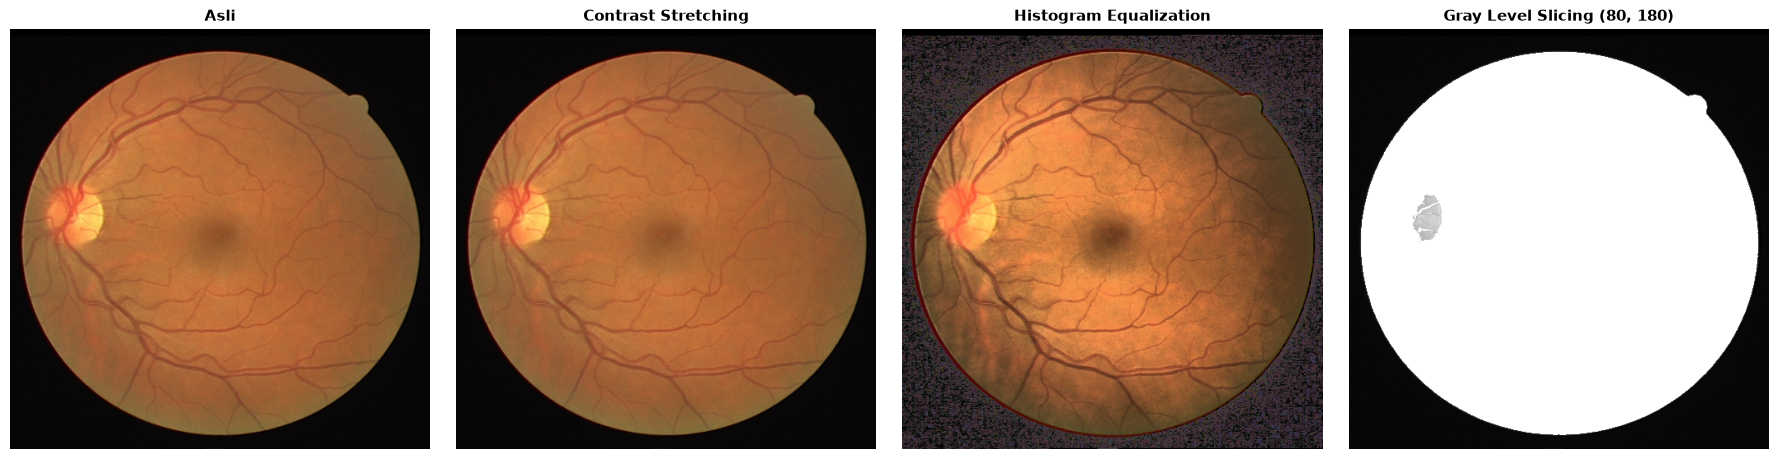

Perbandingan histogram citra low contrast (low-contrast.png):


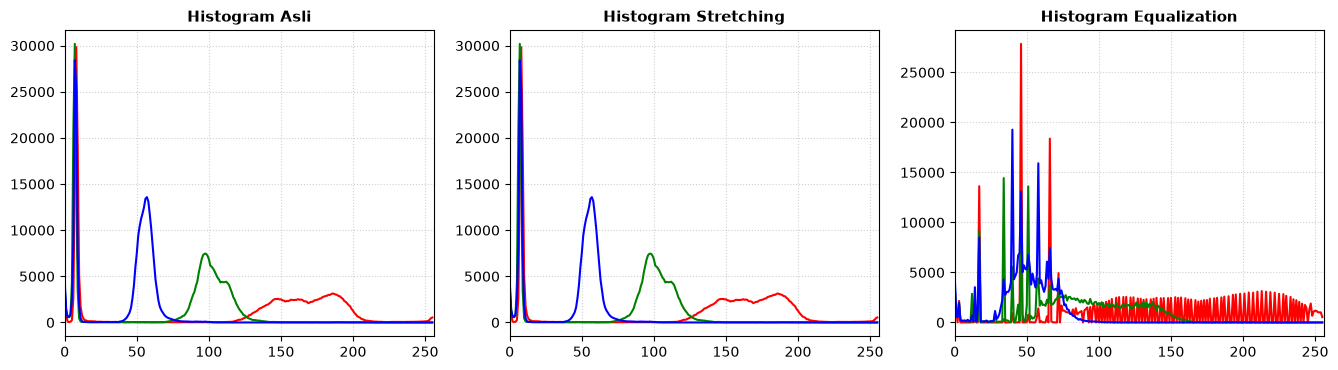

Analisis bit plane slicing citra low contrast (low-contrast.png):


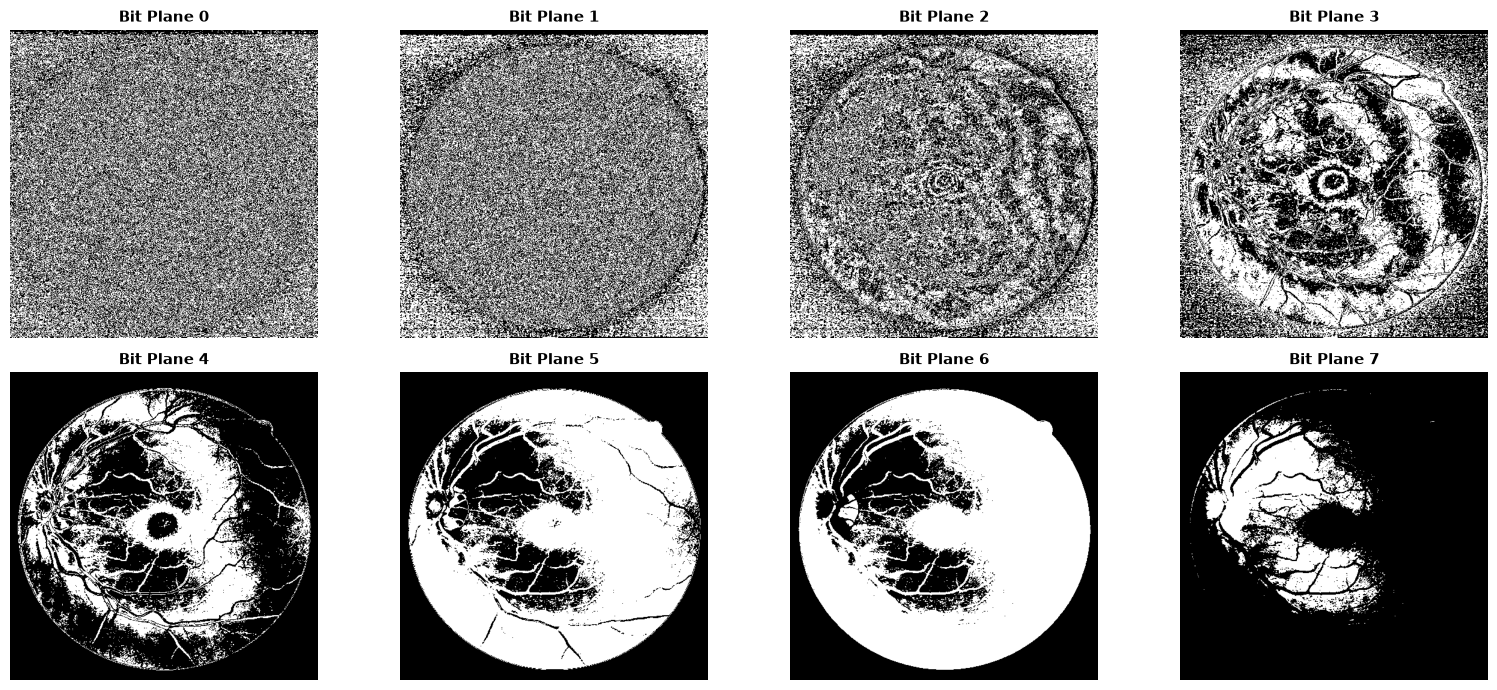

In [22]:
for gambar, nama in zip(dataset["low-contrast"]["gambar"], dataset["low-contrast"]["nama_file"]):
    hasil_stretch = contrast_stretching(gambar)
    hasil_eq = histogram_equalization_color(gambar)
    hasil_slicing = gray_level_slicing(gambar, batas_bawah=80, batas_atas=180)
    
    print(f"Perbandingan visual citra low contrast ({nama}):")
    tampilkan_perbandingan([gambar, hasil_stretch, hasil_eq, hasil_slicing],
                            ["Asli", "Contrast Stretching", "Histogram Equalization", "Gray Level Slicing (80, 180)"])
    
    print(f"Perbandingan histogram citra low contrast ({nama}):")
    tampilkan_histogram([gambar, hasil_stretch, hasil_eq],
                         ["Histogram Asli", "Histogram Stretching", "Histogram Equalization"])
    
    print(f"Analisis bit plane slicing citra low contrast ({nama}):")
    planes = bit_plane_slicing(gambar)
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()
    for i, (ax, plane) in enumerate(zip(axes, planes)):
        ax.imshow(plane, cmap="gray")
        ax.set_title(f"Bit Plane {i}", fontsize=11, fontweight="bold")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### Penjelasan Hasil Percobaan Kategori Low Contrast

Metode yang diuji adalah contrast stretching, histogram equalization pada kanal Value HSV, gray level slicing pada rentang 80 hingga 180, serta analisis bit plane slicing dari bit 0 sampai bit 7.

Citra low contrast memiliki rentang nilai intensitas yang sempit sehingga objek sulit dibedakan dari latar belakang. Contrast stretching dan histogram equalization dirancang untuk memperluas rentang dinamis piksel ke skala penuh 0 hingga 255.

Secara visual, histogram equalization mempertegas batas objek secara nyata dengan kurva histogram yang merata ke seluruh rentang dinamis. Gray level slicing berhasil menonjolkan area target menjadi terang benderang. Hasil pembedahan bit plane slicing memperlihatkan bahwa bit 7, 6, dan 5 membawa struktur visual utama citra, sedangkan bit 0 hanya memuat variasi acak semata.

Histogram equalization terbukti paling efektif meningkatkan kontras global citra low contrast, dengan konfirmasi dekomposisi bit plane bahwa informasi bentuk tersimpan pada bit berorde tinggi.

## 8. Enhancement Kategori Blur

Menerapkan unsharp masking dan laplacian sharpening untuk penajaman, serta mean filter dan gaussian filter sebagai pembanding pembuktian teori pemulusan.

Perbandingan visual citra blur (blur.jpg):


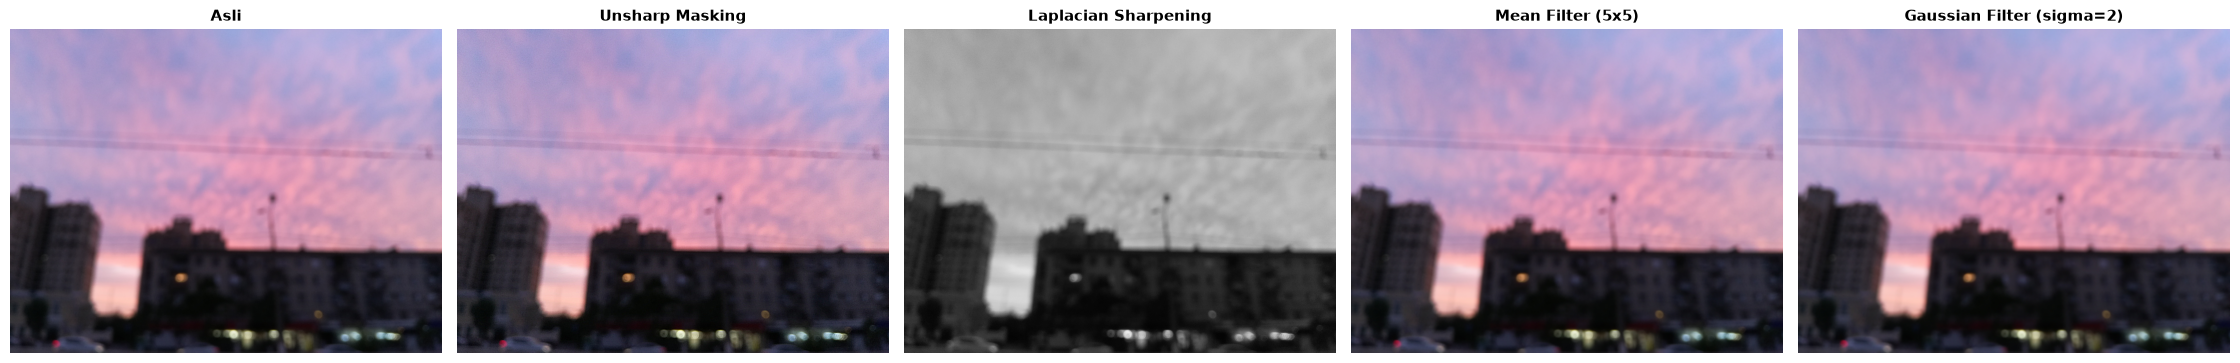

In [23]:
for gambar, nama in zip(dataset["blur"]["gambar"], dataset["blur"]["nama_file"]):
    hasil_unsharp = unsharp_masking(gambar, sigma=3, alpha=1.5)
    hasil_laplacian = laplacian_sharpening(gambar)
    hasil_mean = mean_filter(gambar, ukuran_kernel=5)
    hasil_gaussian = gaussian_filter(gambar, sigma=2)
    
    print(f"Perbandingan visual citra blur ({nama}):")
    tampilkan_perbandingan([gambar, hasil_unsharp, hasil_laplacian, hasil_mean, hasil_gaussian],
                            ["Asli", "Unsharp Masking", "Laplacian Sharpening", "Mean Filter (5x5)", "Gaussian Filter (sigma=2)"])

### Penjelasan Hasil Percobaan Kategori Blur

Metode yang diuji adalah unsharp masking dengan rumus g = f + alpha dikali detail tepi pada sigma 3 dan alpha 1.5, laplacian sharpening dengan operator turunan kedua spasial, serta pembanding mean filter 5x5 dan gaussian filter sigma 2.

Citra blur kehilangan ketegasan pada batas tepi objek. Unsharp masking dan laplacian sharpening menambahkan komponen turunan spasial kembali ke citra asli untuk mempertajam kontur. Filter mean dan gaussian diuji sebagai pembuktian teori bahwa pemulusan justru memperparah kekaburan.

Secara visual, unsharp masking berhasil mengembalikan ketajaman garis tepi objek secara natural tanpa memicu gangguan derau. Laplacian sharpening memberikan penajaman yang sangat tegas pada batas objek. Sebaliknya, mean filter dan gaussian filter membuat citra semakin kabur dan memudarkan batas objek.

Unsharp masking terbukti paling efektif memulihkan kejernihan citra blur, sementara filter pemulus terbukti secara teoritis memperburuk kondisi blur.

## 9. Enhancement Kategori Noisy

Menerapkan median filter, mean filter, dan gaussian filter pada citra yang mengalami gangguan derau impuls salt and pepper.

Perbandingan visual citra noisy (noisy.jpg):


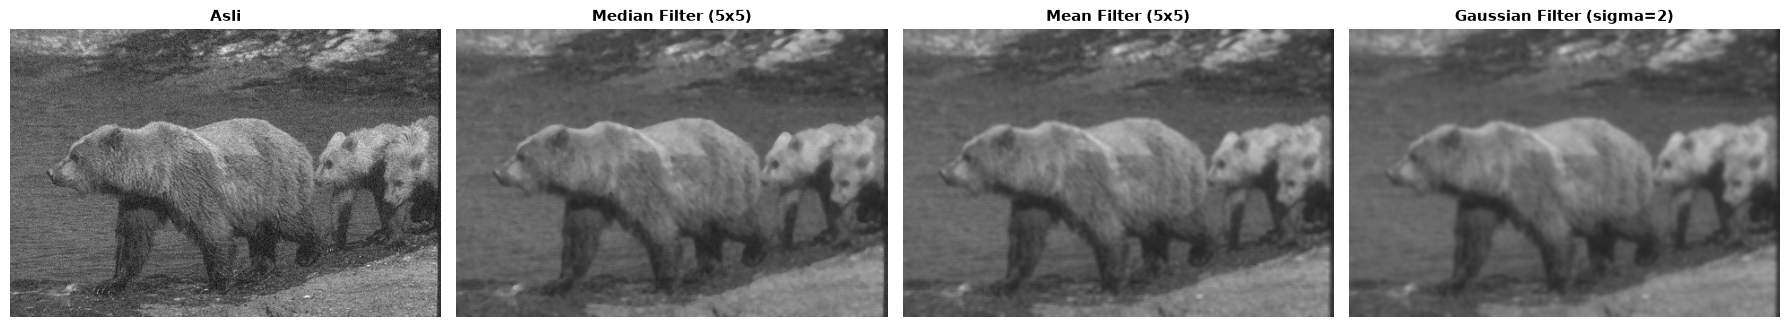

In [24]:
for gambar, nama in zip(dataset["noisy"]["gambar"], dataset["noisy"]["nama_file"]):
    hasil_median = median_filter(gambar, ukuran_kernel=5)
    hasil_mean = mean_filter(gambar, ukuran_kernel=5)
    hasil_gaussian = gaussian_filter(gambar, sigma=2)
    
    print(f"Perbandingan visual citra noisy ({nama}):")
    tampilkan_perbandingan([gambar, hasil_median, hasil_mean, hasil_gaussian],
                            ["Asli", "Median Filter (5x5)", "Mean Filter (5x5)", "Gaussian Filter (sigma=2)"])

### Penjelasan Hasil Percobaan Kategori Noisy

Metode yang diuji adalah median filter kernel 5x5, mean filter kernel 5x5, dan gaussian filter dengan sigma 2.

Citra noisy mengalami gangguan derau impuls salt and pepper berupa bintik bintik ekstrem hitam dan putih secara acak. Median filter sangat cocok karena memilih nilai tengah dari tetangga lokal sehingga nilai ekstrem derau terabaikan tanpa merusak tepi objek.

Secara visual, median filter berhasil membersihkan seluruh titik derau hitam dan putih secara tuntas sembari menjaga ketegasan batas objek. Sebaliknya, mean filter dan gaussian filter gagal menghilangkan derau dan hanya menyebarkannya menjadi bercak bercak abu abu buram yang mengaburkan citra.

Median filter terbukti paling unggul dan tepat untuk menangani derau impuls pada citra digital.

## 10. Kesimpulan

Berdasarkan seluruh hasil eksperimen visual dan analisis histogram pada lima kelompok citra diperoleh kesimpulan berikut:

* **Low Light:** Gamma transform 0.4 dan histogram equalization terbukti paling efektif mencerahkan area gelap secara merata dan natural tanpa menghasilkan silau berlebih.
* **Over Exposed:** Gamma transform 2.2 terbukti paling berhasil meredam area silau terang dan memunculkan kembali detail tekstur permukaan objek.
* **Low Contrast:** Histogram equalization terbukti paling unggul memperluas rentang dinamis citra, didukung analisis bit plane yang membuktikan bahwa informasi struktur visual dominan tersimpan pada bit berorde tinggi.
* **Blur:** Unsharp masking terbukti paling optimal menajamkan batas kontur tepi objek secara alami, sedangkan filter perata terbukti memperparah kekaburan.
* **Noisy:** Median filter terbukti mutlak paling unggul menghilangkan derau impuls salt and pepper secara sempurna tanpa merusak batas ketajaman tepi objek.